# SuperMarket Data Analytics

**Student:** ChandhraShekhar  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship Program  

This notebook follows **DATA → INFORMATION → INSIGHT → DECISION → ACTION** using the supplied supermarket table.

## 1. Load and inspect the supplied dataset
The PDF table was extracted into `dataset/supermarket_data.csv`. The original PDF is preserved outside the submission folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

DATA_PATH = Path('dataset/supermarket_data.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
df.info()

Shape: (500, 13)


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4.0,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9.0,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3.0,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2.0,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5.0,130.57,Cash,3.1,652.85


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     500 non-null    str    
 1   Date           500 non-null    str    
 2   Branch         500 non-null    str    
 3   City           500 non-null    str    
 4   Customer Type  500 non-null    str    
 5   Gender         500 non-null    str    
 6   Product        500 non-null    str    
 7   Category       500 non-null    str    
 8   Quantity       500 non-null    float64
 9   Unit Price     500 non-null    float64
 10  Payment        500 non-null    str    
 11  Rating         500 non-null    float64
 12  Sales          500 non-null    float64
dtypes: float64(4), str(9)
memory usage: 77.9 KB


## 2. Data quality analysis and cleaning
The source table is checked for missing values, duplicates, invalid dates, impossible numerical values, and Sales formula consistency. Valid records are retained; invalid records would be excluded from the cleaned analysis dataframe rather than silently changed.

In [2]:
quality = pd.DataFrame({'Missing values': df.isna().sum(), 'Unique values': df.nunique()})
display(quality)
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate invoice IDs:', df['Invoice ID'].duplicated().sum())
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Invalid ratings:', ((pd.to_numeric(df['Rating'], errors='coerce') < 0) | (pd.to_numeric(df['Rating'], errors='coerce') > 5)).sum())
formula_difference = (df['Sales'] - df['Quantity'] * df['Unit Price']).round(2)
print('Sales formula mismatches beyond 0.01:', (formula_difference.abs() > 0.01).sum())
clean = df.copy()
clean['Date'] = pd.to_datetime(clean['Date'], errors='coerce')
clean = clean.dropna(subset=['Date']).copy()
clean = clean[(clean['Quantity'] > 0) & (clean['Unit Price'] > 0) & clean['Rating'].between(0,5) & (clean['Sales'] > 0)].copy()
clean['Year'] = clean['Date'].dt.year
clean['Month'] = clean['Date'].dt.month
clean['Month Name'] = clean['Date'].dt.strftime('%b')
clean['Day'] = clean['Date'].dt.day
clean['Day of Week'] = clean['Date'].dt.day_name()
print('Clean rows:', len(clean))

,Missing values,Unique values
Invoice ID,0,500
Date,0,173
Branch,0,4
City,0,4
Customer Type,0,2
Gender,0,2
Product,0,20
Category,0,8
Quantity,0,10
Unit Price,0,488


Duplicate rows: 0
Duplicate invoice IDs: 0
Date range: 2026-01-01 to 2026-07-01
Invalid ratings: 0
Sales formula mismatches beyond 0.01: 0
Clean rows: 500


## 3. KPI analysis and exploratory analysis

,Value
Total sales,244411.08000
Transactions,500.00000
Quantity sold,2768.00000
Average transaction,488.82216
Average rating,3.99440


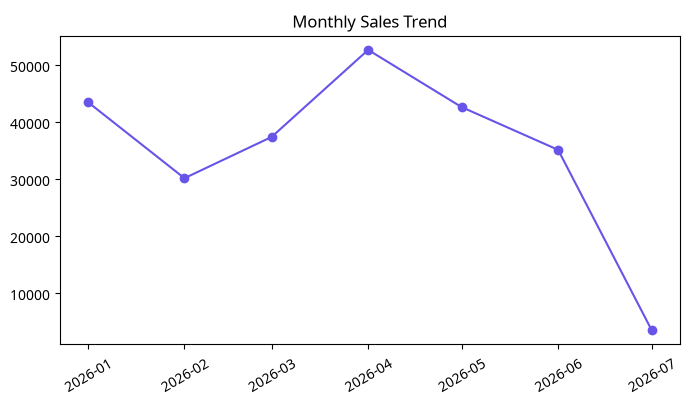

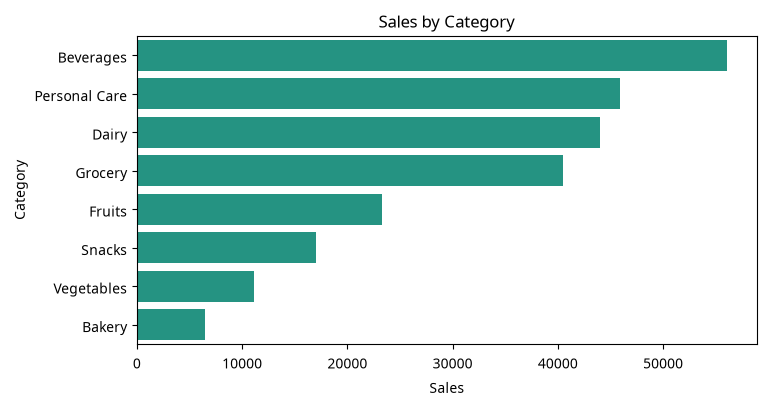

,Branch,City,Sales
2,C,Mumbai,72469.45
1,B,Delhi,64116.26
3,D,Bengaluru,55468.29
0,A,Jaipur,52357.08


In [3]:
kpis = {'Total sales': clean['Sales'].sum(), 'Transactions': clean['Invoice ID'].nunique(), 'Quantity sold': clean['Quantity'].sum(), 'Average transaction': clean['Sales'].mean(), 'Average rating': clean['Rating'].mean()}
display(pd.Series(kpis).to_frame('Value'))
monthly = clean.groupby(clean['Date'].dt.to_period('M'))['Sales'].sum().reset_index(); monthly['Date'] = monthly['Date'].dt.to_timestamp()
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(monthly['Date'], monthly['Sales'], marker='o', color='#6754e8'); ax.set_title('Monthly Sales Trend'); ax.tick_params(axis='x', rotation=30); plt.show()
category_sales = clean.groupby('Category', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
fig, ax = plt.subplots(figsize=(8,4)); sns.barplot(data=category_sales, x='Sales', y='Category', ax=ax, color='#13a58e'); ax.set_title('Sales by Category'); plt.show()
branch_sales = clean.groupby(['Branch','City'], as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
display(branch_sales)

## 4. Predictive analytics: Rating prediction
Sales is not used as a target because it is mathematically derived from Quantity × Unit Price. Instead, the model estimates customer Rating from transaction and context features. This is an exploratory prioritization model, not a causal claim and not a replacement for collecting actual feedback.

,Value
Baseline MAE,0.472490
Model MAE,0.492477
Model RMSE,0.573958
Model R2,-0.191530


,Feature,Importance
7,Unit Price,0.011734
2,Customer Type,0.004159
8,Payment,0.001324
3,Gender,0.001077
5,Category,0.000876
9,Month,-0.000877
4,Product,-0.001577
0,Branch,-0.006065
1,City,-0.006552
6,Quantity,-0.007715


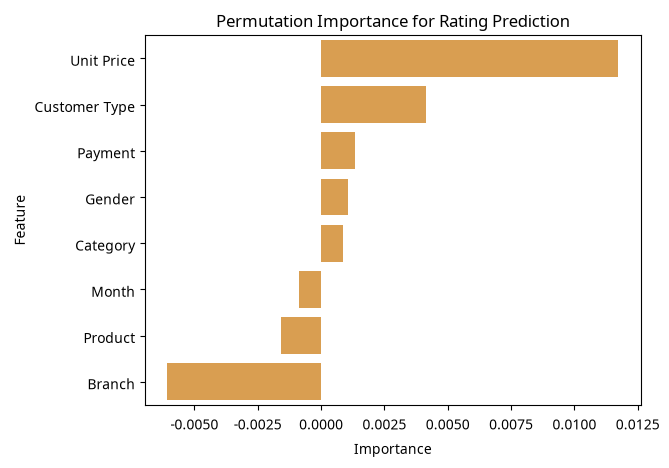

In [4]:
features = ['Branch','City','Customer Type','Gender','Product','Category','Quantity','Unit Price','Payment','Month','Day of Week']
target = 'Rating'
X, y = clean[features], clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat = [c for c in features if not pd.api.types.is_numeric_dtype(X[c])]; num = [c for c in features if c not in cat]
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat), ('num', 'passthrough', num)])
model = Pipeline([('preprocess', pre), ('model', RandomForestRegressor(n_estimators=250, max_depth=8, min_samples_leaf=2, random_state=42))])
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train); model.fit(X_train, y_train)
pred = model.predict(X_test)
model_metrics = {'Baseline MAE': mean_absolute_error(y_test, baseline.predict(X_test)), 'Model MAE': mean_absolute_error(y_test, pred), 'Model RMSE': mean_squared_error(y_test, pred) ** 0.5, 'Model R2': r2_score(y_test, pred)}
display(pd.Series(model_metrics).to_frame('Value'))
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
importance = pd.DataFrame({'Feature': features, 'Importance': perm.importances_mean}).sort_values('Importance', ascending=False)
display(importance)
sns.barplot(data=importance.head(8), x='Importance', y='Feature', color='#f0a13a'); plt.title('Permutation Importance for Rating Prediction'); plt.show()

## 5. FACT → INSIGHT → OPPORTUNITY/RISK → ACTION

- **Fact:** The leading category and city are identified from cleaned Sales totals. **Insight:** Sales contribution is concentrated in identifiable categories and locations. **Opportunity/Risk:** Availability and execution in leading segments matter, while over-reliance creates exposure. **Action:** Monitor inventory and compare the leading city/category with lower-performing segments.
- **Fact:** Sales is deterministically related to Quantity and Unit Price. **Insight:** A Sales model would reproduce a formula rather than add intelligence. **Action:** Use the Rating model only as an exploratory signal and improve feedback capture before operationalizing prediction.

## 6. Limitations and conclusion
The PDF table is a static six-month extract. It supports descriptive analysis and an exploratory rating model, but it does not establish causation, customer lifetime value, inventory availability, or promotional uplift.

## 7. Expanded analysis documentation

This section makes the notebook a complete internship submission. It keeps the original analysis and adds a documented data dictionary, outlier checks, descriptive statistics, segment analyses, time analysis, and business explanations. Every result below is calculated from `dataset/supermarket_data.csv`.

### Business problem and objective

The business needs a reliable view of sales performance, product and category contribution, branch and city differences, customer mix, payment behavior, and customer ratings. The objective is to convert validated transactions into decisions without inventing profit, retention, churn, or causal claims.

### Dataset dictionary

The source contains Invoice ID, Date, Branch, City, Customer Type, Gender, Product, Category, Quantity, Unit Price, Payment, Rating, and Sales. Derived fields are used only for analysis: Year, Month, Month Name, Day, and Day of Week.

In [5]:
column_dictionary = pd.DataFrame({
    "Column": df.columns[:13],
    "Meaning": [
        "Unique transaction identifier", "Transaction date", "Branch code", "City", "Member or Normal",
        "Customer gender", "Product name", "Product category", "Units in transaction", "Price per unit",
        "Payment method", "Customer rating from 0 to 5", "Transaction sales value"
    ],
    "Type": [str(df[c].dtype) for c in df.columns[:13]]
})
display(column_dictionary)

,Column,Meaning,Type
0,Invoice ID,Unique transaction identifier,str
1,Date,Transaction date,str
2,Branch,Branch code,str
3,City,City,str
4,Customer Type,Member or Normal,str
5,Gender,Customer gender,str
6,Product,Product name,str
7,Category,Product category,str
8,Quantity,Units in transaction,float64
9,Unit Price,Price per unit,float64


### Data quality and outlier assessment

Missing values, duplicates, ranges, dates, and the deterministic Sales formula are checked before analysis. Outlier checks are descriptive only; valid high-value transactions are not silently removed.

In [6]:
quality_summary = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Unique": df.nunique(),
    "Dtype": df.dtypes.astype(str)
})
display(quality_summary)
print("Duplicate rows:", int(df.duplicated().sum()))
print("Duplicate Invoice IDs:", int(df["Invoice ID"].duplicated().sum()))
date_check = pd.to_datetime(df["Date"], errors="coerce")
print("Date range:", date_check.min().date(), "to", date_check.max().date())
print("Invalid quantity:", int((df["Quantity"] <= 0).sum()))
print("Invalid unit price:", int((df["Unit Price"] <= 0).sum()))
print("Invalid rating:", int((~df["Rating"].between(0, 5)).sum()))
print("Sales formula mismatches:", int(((df["Sales"] - df["Quantity"] * df["Unit Price"]).abs() > 0.01).sum()))
num_summary = df[["Quantity", "Unit Price", "Rating", "Sales"]].describe().T
display(num_summary)
q1, q3 = df["Sales"].quantile([0.25, 0.75]); iqr=q3-q1
outliers = df[(df["Sales"] < q1-1.5*iqr) | (df["Sales"] > q3+1.5*iqr)]
print("Descriptive Sales outlier count (not removed):", len(outliers))

,Missing,Unique,Dtype
Invoice ID,0,500,str
Date,0,173,str
Branch,0,4,str
City,0,4,str
Customer Type,0,2,str
Gender,0,2,str
Product,0,20,str
Category,0,8,str
Quantity,0,10,float64
Unit Price,0,488,float64


Duplicate rows: 0
Duplicate Invoice IDs: 0
Date range: 2026-01-01 to 2026-07-01
Invalid quantity: 0
Invalid unit price: 0
Invalid rating: 0
Sales formula mismatches: 0


,count,mean,std,min,25%,50%,75%,max
Quantity,500.0,5.53600,2.875629,1.00,3.0000,5.50,8.0000,10.00
Unit Price,500.0,88.66070,57.284029,27.67,43.9550,61.88,128.5675,236.71
Rating,500.0,3.99440,0.574481,3.00,3.5000,4.00,4.5000,5.00
Sales,500.0,488.82216,437.327833,28.61,189.2125,335.91,609.8850,2114.82


Descriptive Sales outlier count (not removed): 51


### Sales and time analysis — FACT → INSIGHT → OPPORTUNITY/RISK → ACTION

**Fact:** Monthly sales totals are calculated from transaction Sales. **Insight:** The month-to-month pattern shows where sales concentration occurs in this extract. **Opportunity/Risk:** A short static period can make a month appear stronger without proving a long-term trend. **Action:** Use the monthly pattern for review and combine it with longer history before changing targets.

,Date,sum,count,mean,Month
0,2026-01,43415.53,88,493.358295,2026-01
1,2026-02,30068.15,65,462.586923,2026-02
2,2026-03,37306.42,83,449.474940,2026-03
3,2026-04,52569.77,90,584.108556,2026-04
4,2026-05,42542.31,85,500.497765,2026-05
5,2026-06,35041.46,82,427.334878,2026-06
6,2026-07,3467.44,7,495.348571,2026-07


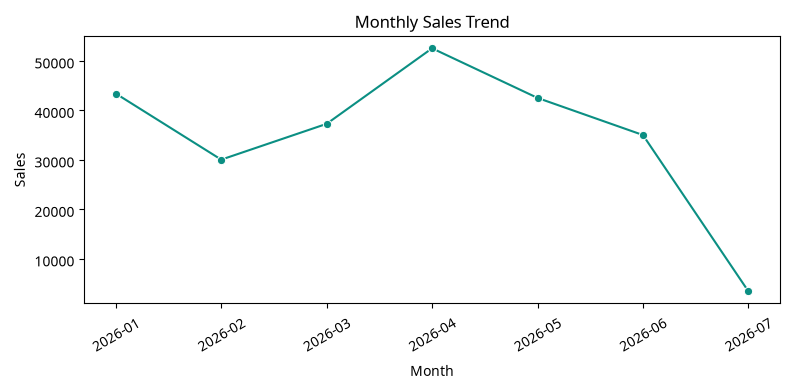

In [7]:
monthly_analysis = clean.groupby(clean["Date"].dt.to_period("M"))["Sales"].agg(["sum","count","mean"]).reset_index()
monthly_analysis["Month"] = monthly_analysis["Date"].astype(str)
display(monthly_analysis)
fig, ax = plt.subplots(figsize=(8,4))
sns.lineplot(data=monthly_analysis, x="Month", y="sum", marker="o", color="#0b8f83", ax=ax)
ax.set(title="Monthly Sales Trend", xlabel="Month", ylabel="Sales")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

### Product and category analysis — FACT → INSIGHT → OPPORTUNITY/RISK → ACTION

**Fact:** Category and product totals are ranked by Sales and Quantity. **Insight:** The leading items represent the strongest observed contribution in this sample. **Opportunity/Risk:** Concentration can support availability planning but can also create dependency on a narrow mix. **Action:** Benchmark availability and execution for leading items while reviewing lower-performing items before reallocating effort.

,Sales,Quantity,Transactions,Average_Rating
Category,,,,
Beverages,56108.24,465.0,82,3.958537
Personal Care,45943.96,399.0,73,3.953425
Dairy,43992.00,345.0,68,4.030882
Grocery,40470.47,439.0,82,3.941463
Fruits,23263.17,223.0,44,3.829545
Snacks,16992.97,443.0,75,4.108000
Vegetables,11124.17,290.0,48,3.985417
Bakery,6516.10,164.0,28,4.242857


,Sales,Quantity,Transactions
Product,,,
Cheese,27906.30,126.0,26
Coffee,27694.87,153.0,24
Shampoo,27497.48,152.0,27
Cooking Oil,21525.06,142.0,26
Tea,17681.59,146.0,29
Apples,17057.41,119.0,20
Face Wash,11946.85,100.0,19
Rice,11754.17,167.0,29
Cold Drink,10731.78,166.0,29


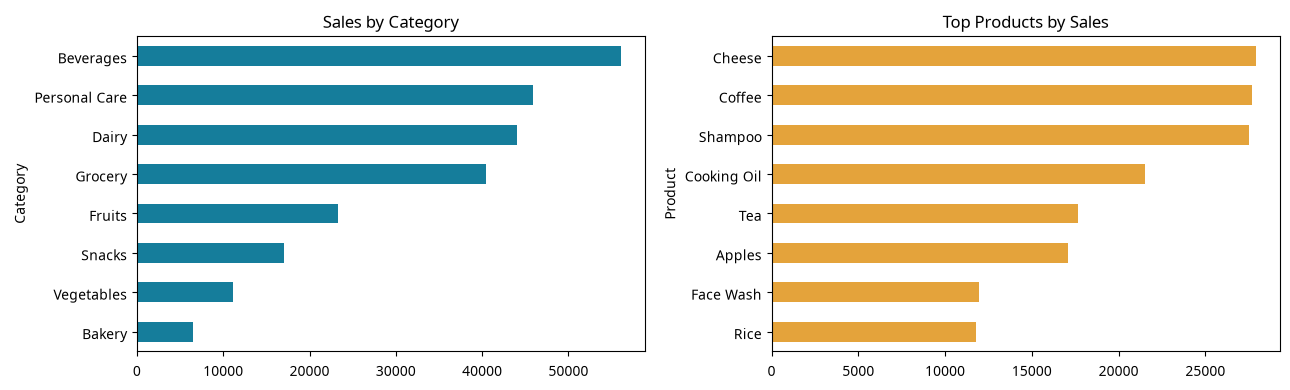

In [8]:
category_analysis = clean.groupby("Category").agg(Sales=("Sales","sum"), Quantity=("Quantity","sum"), Transactions=("Invoice ID","nunique"), Average_Rating=("Rating","mean")).sort_values("Sales", ascending=False)
product_analysis = clean.groupby("Product").agg(Sales=("Sales","sum"), Quantity=("Quantity","sum"), Transactions=("Invoice ID","nunique")).sort_values("Sales", ascending=False)
display(category_analysis)
display(product_analysis.head(10))
fig, axes = plt.subplots(1,2,figsize=(13,4))
category_analysis["Sales"].sort_values().plot.barh(ax=axes[0], color="#157d9b", title="Sales by Category")
product_analysis.head(8)["Sales"].sort_values().plot.barh(ax=axes[1], color="#e4a33b", title="Top Products by Sales")
plt.tight_layout(); plt.show()

### Branch, city, customer, payment, and rating analysis

**Fact:** Segment tables below calculate sales, quantity, transaction count, average transaction value, and rating from actual fields. **Insight:** Differences identify where operational review may be useful. **Opportunity/Risk:** These are descriptive associations, not proof that a branch, customer type, payment method, or category caused a result. **Action:** Use the comparisons to prioritize questions and service reviews, then validate with operational data.

In [9]:
branch_city_analysis = clean.groupby(["Branch","City"]).agg(Sales=("Sales","sum"), Quantity=("Quantity","sum"), Transactions=("Invoice ID","nunique"), Average_Transaction=("Sales","mean"), Average_Rating=("Rating","mean")).sort_values("Sales", ascending=False)
customer_analysis = clean.groupby(["Customer Type","Gender"]).agg(Sales=("Sales","sum"), Quantity=("Quantity","sum"), Transactions=("Invoice ID","nunique"), Average_Transaction=("Sales","mean"), Average_Rating=("Rating","mean"))
payment_analysis = clean.groupby("Payment").agg(Sales=("Sales","sum"), Transactions=("Invoice ID","nunique"), Quantity=("Quantity","sum")).sort_values("Transactions", ascending=False)
rating_analysis = clean.groupby("Category").agg(Average_Rating=("Rating","mean"), Ratings=("Rating","count")).sort_values("Average_Rating", ascending=False)
display(branch_city_analysis); display(customer_analysis); display(payment_analysis); display(rating_analysis)

,,Sales,Quantity,Transactions,Average_Transaction,Average_Rating
Branch,City,,,,,
C,Mumbai,72469.45,807.0,143,506.779371,4.046154
B,Delhi,64116.26,692.0,133,482.077143,3.975188
D,Bengaluru,55468.29,669.0,119,466.120084,4.092437
A,Jaipur,52357.08,600.0,105,498.638857,3.837143


Sales  Quantity  Transactions  Average_Transaction  \
Customer Type Gender                                                          
Member        Female  68012.09     803.0           149           456.456980   
              Male    74997.21     856.0           147           510.185102   
Normal        Female  55942.03     577.0           106           527.755000   
              Male    45459.75     532.0            98           463.875000   

                      Average_Rating  
Customer Type Gender                  
Member        Female        4.041611  
              Male          3.985034  
Normal        Female        3.957547  
              Male          3.976531

,Sales,Transactions,Quantity
Payment,,,
UPI,67910.33,127,705.0
Net Banking,65194.93,126,749.0
Card,57265.64,125,665.0
Cash,54040.18,122,649.0


,Average_Rating,Ratings
Category,,
Bakery,4.242857,28
Snacks,4.108000,75
Dairy,4.030882,68
Vegetables,3.985417,48
Beverages,3.958537,82
Personal Care,3.953425,73
Grocery,3.941463,82
Fruits,3.829545,44


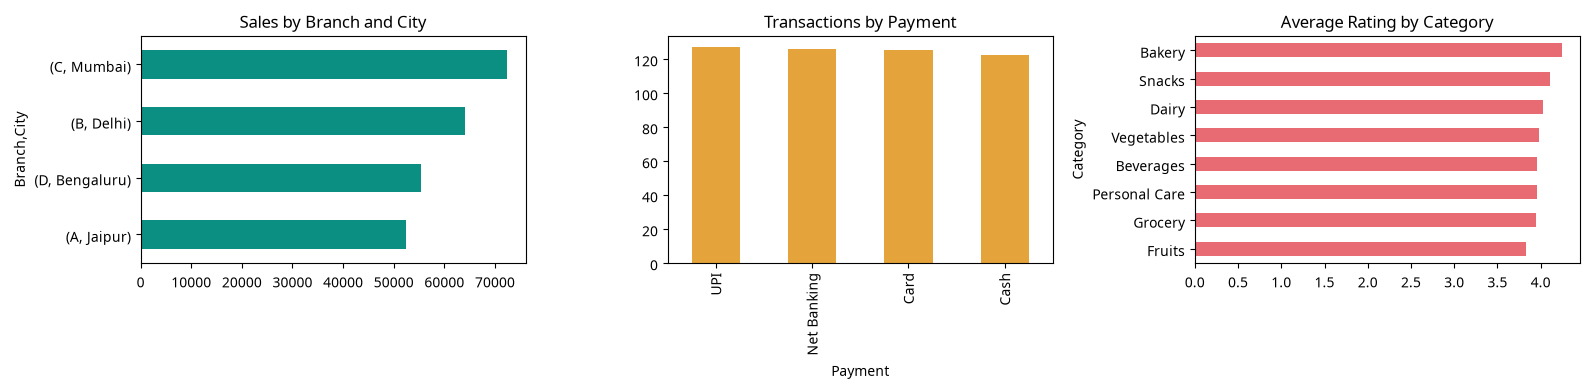

In [10]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
branch_city_analysis["Sales"].sort_values().plot.barh(ax=axes[0], color="#0b8f83", title="Sales by Branch and City")
payment_analysis["Transactions"].plot.bar(ax=axes[1], color="#e4a33b", title="Transactions by Payment")
rating_analysis["Average_Rating"].sort_values().plot.barh(ax=axes[2], color="#e86b73", title="Average Rating by Category")
plt.tight_layout(); plt.show()

### Final conclusion and limitations

The project demonstrates a reproducible analytics workflow from a validated PDF extract to KPIs, trends, segment comparisons, and action-oriented findings. Sales prediction is not forced because Sales is Quantity × Unit Price; the exploratory Rating model is retained only as a transparent experiment and is not presented as an operational forecast. The dataset does not contain margin, inventory, promotion, payment-failure, or longitudinal customer fields, so the analysis cannot establish profitability, retention, churn, or causation.